# 09 — Riemannian QMKL : Combinaison géodésique sur la variété SPD

**Idée centrale** : Remplacer la combinaison linéaire K_lin = Σ w_m K_m par la
**moyenne de Fréchet** (géodésique) sur la variété des matrices SPD :

    K★ = argmin_{K ∈ SPD_n}  Σ_m w_m · d²_R(K, K_m)
         d_R(A,B) = ‖log(A^{-½} B A^{-½})‖_F   (distance de Bures)

**Design expérimental** : pour isoler la contribution géométrique pure, nous
comparons les MÊMES poids (Centered Alignment) appliqués à :
  - K_lin   = Σ w_m K_m                     (combinaison linéaire, référence)
  - K_LogE  = exp(Σ w_m log(K_m))            (Log-Euclidean, O(N³), pas d'itération)
  - K_Fré   = Fréchet mean(K_1,...,K_M; w)   (Riemannian exact, O(N³) × max_iter)

Cela isole l'effet **géométrique** de chaque combinaison indépendamment des poids.

**Figures** (results/09/) :
1. F1 — Illustration géodésique 2D (variété SPD₂)
2. F2 — Convergence itération de Fréchet
3. F3 — Distances de Bures inter-kernels (heatmap)
4. F4 — Spectres propres : linéaire vs Log-Euclidean vs Fréchet
5. F5 — Paysage KTA sur le simplexe 2D (M=3 hardware)
6. F6 — Comparaison AUC multi-méthodes (20 runs)
7. F7 — Application hardware IBM Torino
8. F8 — Tableau de synthèse

In [1]:
import sys, os, warnings, time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.mkl.riemannian_mkl import (
    RiemannianQMKL, frechet_mean, log_euclidean_mean,
    riemannian_dist, geodesic_path, linear_combination,
    matrix_log, matrix_exp, matrix_sqrt,
    riemannian_multi_run_evaluation,
)
from src.mkl.alignment import centered_alignment, sdp_alignment, projection_alignment
from src.evaluation.statistical_analysis import multi_run_evaluation, summarize_multi_run

OUT   = ROOT / 'results' / '09'; OUT.mkdir(parents=True, exist_ok=True)
CACHE = ROOT / 'results' / 'kernel_cache'
HW    = ROOT / 'results' / 'hw_kernel_cache'

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'savefig.bbox': 'tight'})
N_RUNS = 20; SEED = 42; C_SVM = 1.0
print("Riemannian QMKL — Notebook 09"); print(f"Output: {OUT}")

Riemannian QMKL — Notebook 09
Output: /Users/raph/Desktop/Academic/Projet infoQ/Projet-QMKL-Finance/results/09


## 1. Chargement des kernels et étiquettes

In [2]:
from data.loaders import load_dataset

KERNEL_LIBRARY = [
    ('Z_a1.0','Z α=1.0'),    ('Z_a3.0','Z α=3.0'),
    ('ZZ_a1.0','ZZ α=1.0'),  ('ZZ_a4.0','ZZ α=4.0'),
    ('pauli_a0.6','Pauli α=0.6'),    ('pauli_a3.0','Pauli α=3.0'),
    ('pauli_XZ_a0.5','Pauli-XZ α=0.5'),('pauli_XZ_a2.5','Pauli-XZ α=2.5'),
    ('pauli_YXX_a0.6','Pauli-YXX α=0.6'),('pauli_YXX_a3.0','Pauli-YXX α=3.0'),
    ('pauli_YZX_a0.6','Pauli-YZX α=0.6'),('pauli_YZX_a3.0','Pauli-YZX α=3.0'),
]

def load_kernels(prefix, hash_str):
    K_list, names, labels = [], [], []
    for suffix, label in KERNEL_LIBRARY:
        fp = CACHE / f"{prefix}_{suffix}_train_{hash_str}.npy"
        if fp.exists():
            K_list.append(np.load(fp)); names.append(suffix); labels.append(label)
    return K_list, names, labels

K_gc, names_gc, labels_gc = load_kernels('german_credit_fid', '85f488545febc57d')
_, y_gc = load_dataset('german_credit', n_samples=100, random_state=42)

K_bm, names_bm, labels_bm = load_kernels('bank_marketing_fid', '165c651bda07943e')
_, y_bm = load_dataset('bank_marketing', n_samples=100, random_state=42)

K_sy, names_sy, labels_sy = load_kernels('fidelity', '068784b589d509a6')
from sklearn.datasets import make_classification
_, y_sy = make_classification(n_samples=200, n_features=6, n_informative=4,
                               n_redundant=1, random_state=42)

datasets = {
    'German Credit':  (K_gc, y_gc, labels_gc),
    'Bank Marketing': (K_bm, y_bm, labels_bm),
    'Synthétique':    (K_sy, y_sy, labels_sy),
}
for ds, (K, y, _) in datasets.items():
    print(f"{ds}: {len(K)} kernels, shape={K[0].shape}, N={len(y)}")

German Credit: 12 kernels, shape=(100, 100), N=100
Bank Marketing: 12 kernels, shape=(100, 100), N=100
Synthétique: 12 kernels, shape=(200, 200), N=200


## Figure F1 — Géodésique vs droite linéaire sur SPD₂

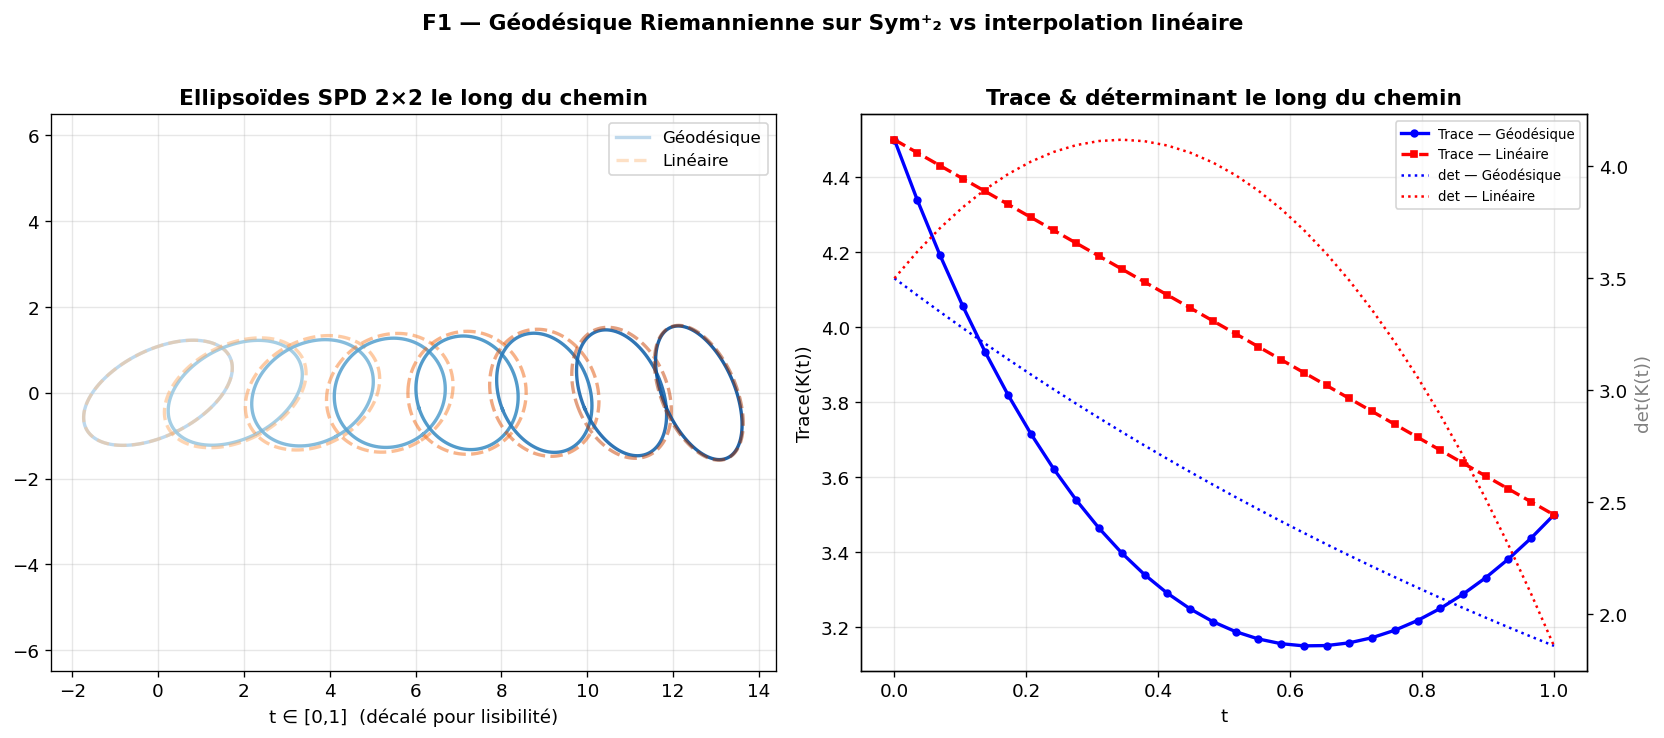

✓ F1


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

K1_2d = np.array([[3.0, 1.0], [1.0, 1.5]])
K2_2d = np.array([[1.0, -0.8], [-0.8, 2.5]])

ts_geo, path_geo = geodesic_path(K1_2d, K2_2d, n_points=30)
path_lin = [t*K2_2d + (1-t)*K1_2d for t in ts_geo]

def ellipse_pts(K, n=120):
    theta = np.linspace(0, 2*np.pi, n)
    v = np.stack([np.cos(theta), np.sin(theta)])
    eig, U = np.linalg.eigh(K)
    eig = np.maximum(eig, 1e-10)
    return U @ np.diag(np.sqrt(eig)) @ v

ax = axes[0]
c_geo = plt.cm.Blues(np.linspace(0.3, 0.9, len(path_geo)))
c_lin = plt.cm.Oranges(np.linspace(0.3, 0.9, len(path_lin)))
for i, (Kg, Kl) in enumerate(zip(path_geo, path_lin)):
    if i % 4 == 0:
        shift = i * 0.45
        pg = ellipse_pts(Kg); pl = ellipse_pts(Kl)
        ax.plot(pg[0]+shift, pg[1], color=c_geo[i], lw=2, alpha=0.9,
                label='Géodésique' if i==0 else None)
        ax.plot(pl[0]+shift, pl[1], color=c_lin[i], lw=2, alpha=0.5,
                ls='--', label='Linéaire' if i==0 else None)
ax.legend(fontsize=10, loc='upper right')
ax.set_title("Ellipsoïdes SPD 2×2 le long du chemin", fontweight='bold')
ax.set_xlabel("t ∈ [0,1]  (décalé pour lisibilité)")
ax.axis('equal'); ax.grid(alpha=0.3)

ax = axes[1]
traces_geo = [np.trace(K) for K in path_geo]
traces_lin = [np.trace(K) for K in path_lin]
dets_geo   = [np.linalg.det(K) for K in path_geo]
dets_lin   = [np.linalg.det(K) for K in path_lin]

ax.plot(ts_geo, traces_geo, 'b-o', ms=4, lw=2, label='Trace — Géodésique')
ax.plot(ts_geo, traces_lin, 'r--s', ms=4, lw=2, label='Trace — Linéaire')
ax2 = ax.twinx()
ax2.plot(ts_geo, dets_geo, 'b:', ms=3, lw=1.5, label='det — Géodésique')
ax2.plot(ts_geo, dets_lin, 'r:', ms=3, lw=1.5, label='det — Linéaire')
ax.set_xlabel("t"); ax.set_ylabel("Trace(K(t))")
ax2.set_ylabel("det(K(t))", color='gray')
ax.set_title("Trace & déterminant le long du chemin", fontweight='bold')
ln1,lb1 = ax.get_legend_handles_labels()
ln2,lb2 = ax2.get_legend_handles_labels()
ax.legend(ln1+ln2, lb1+lb2, fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle("F1 — Géodésique Riemannienne sur Sym⁺₂ vs interpolation linéaire",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT/'09_F1_geodesic.png', dpi=150); plt.show()
print("✓ F1")

## Figure F2 — Convergence de l'itération de Moakher

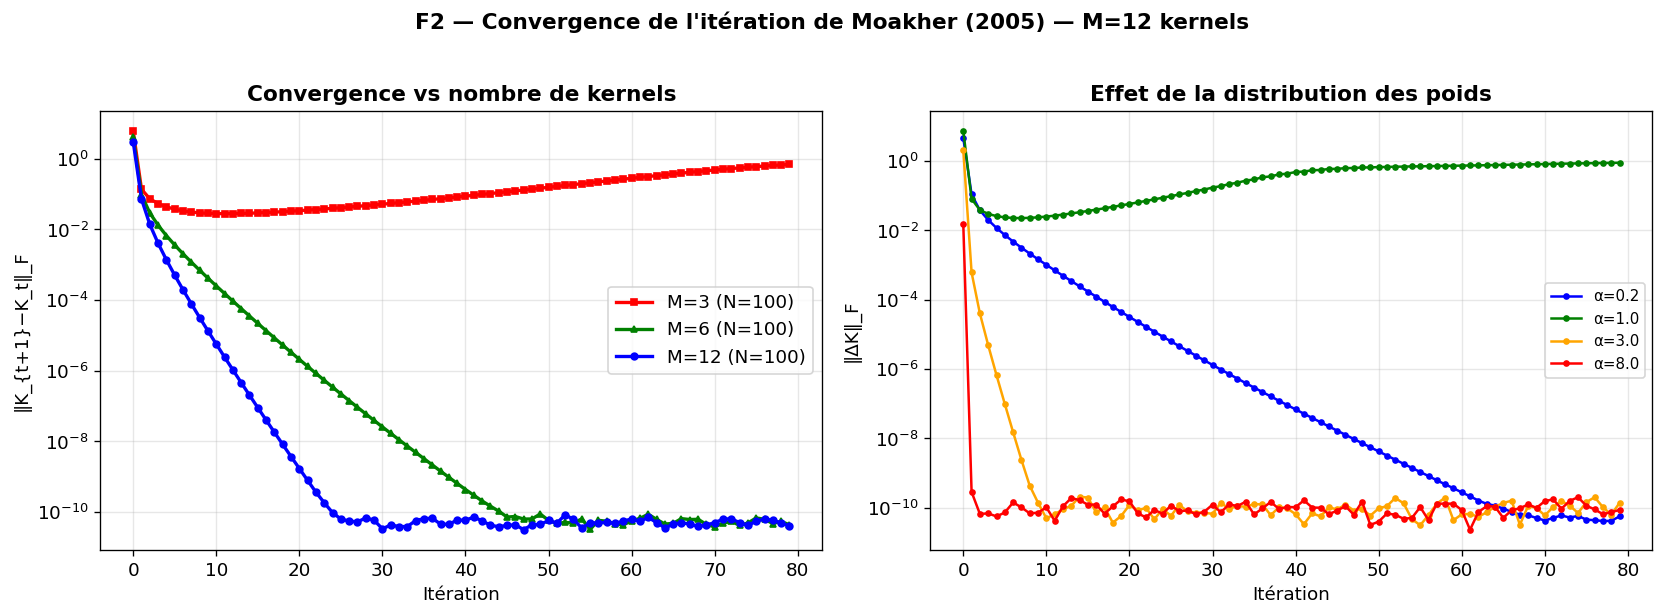

✓ F2


In [4]:
def frechet_track(K_list, weights, eps=1e-8, max_iter=80, tol=1e-14):
    M = len(K_list); n = K_list[0].shape[0]
    w = np.array(weights); w /= w.sum()
    K_reg = [K+eps*np.eye(n) for K in K_list]
    K = (lambda Ks,ws: sum(a*b for a,b in zip(ws,Ks)))(K_reg,w); K=(K+K.T)/2
    diffs = []
    for _ in range(max_iter):
        ev,evec = np.linalg.eigh((K+K.T)/2); ev=np.maximum(ev,eps)
        Ksq  = evec@np.diag(np.sqrt(ev))@evec.T
        Kisq = evec@np.diag(1/np.sqrt(ev))@evec.T
        S = np.zeros((n,n))
        for ww,Km in zip(w,K_reg):
            Mi=(Kisq@Km@Kisq); Mi=(Mi+Mi.T)/2
            ev2,ev2c=np.linalg.eigh(Mi); ev2=np.maximum(ev2,eps)
            S += ww*(ev2c@np.diag(np.log(ev2))@ev2c.T)
        evs,evsc=np.linalg.eigh(S)
        expS=evsc@np.diag(np.exp(evs))@evsc.T
        Kn=(Ksq@expS@Ksq); Kn=(Kn+Kn.T)/2
        diff=np.linalg.norm(Kn-K,'fro'); diffs.append(diff); K=Kn
        if diff<tol: break
    return K, diffs

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for M_sub, col, mk in [(3,'r','s'),(6,'g','^'),(12,'b','o')]:
    Ks = K_gc[:M_sub]
    _, diffs = frechet_track(Ks, np.ones(M_sub)/M_sub)
    ax.semilogy(diffs, f'{col}-{mk}', ms=4, lw=2, label=f'M={M_sub} (N=100)')
ax.set_xlabel("Itération"); ax.set_ylabel("‖K_{t+1}−K_t‖_F")
ax.set_title("Convergence vs nombre de kernels", fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
for alpha, col in zip([0.2, 1.0, 3.0, 8.0], ['b','g','orange','r']):
    w = np.exp(-alpha*np.arange(len(K_gc), dtype=float)); w/=w.sum()
    _, diffs = frechet_track(K_gc, w)
    ax.semilogy(diffs, '-o', ms=3, lw=1.5, color=col, label=f'α={alpha:.1f}')
ax.set_xlabel("Itération"); ax.set_ylabel("‖ΔK‖_F")
ax.set_title("Effet de la distribution des poids", fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle("F2 — Convergence de l'itération de Moakher (2005) — M=12 kernels",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT/'09_F2_frechet_convergence.png', dpi=150); plt.show()
print("✓ F2")

## Figure F3 — Distances de Bures inter-kernels

Distances German Credit... 

0.9s


  d_max=28.696, d_mean=10.982
Distances Bank Marketing... 

1.1s
  d_max=49.184, d_mean=16.530
Distances Synthétique... 

5.0s
  d_max=54.750, d_mean=20.284


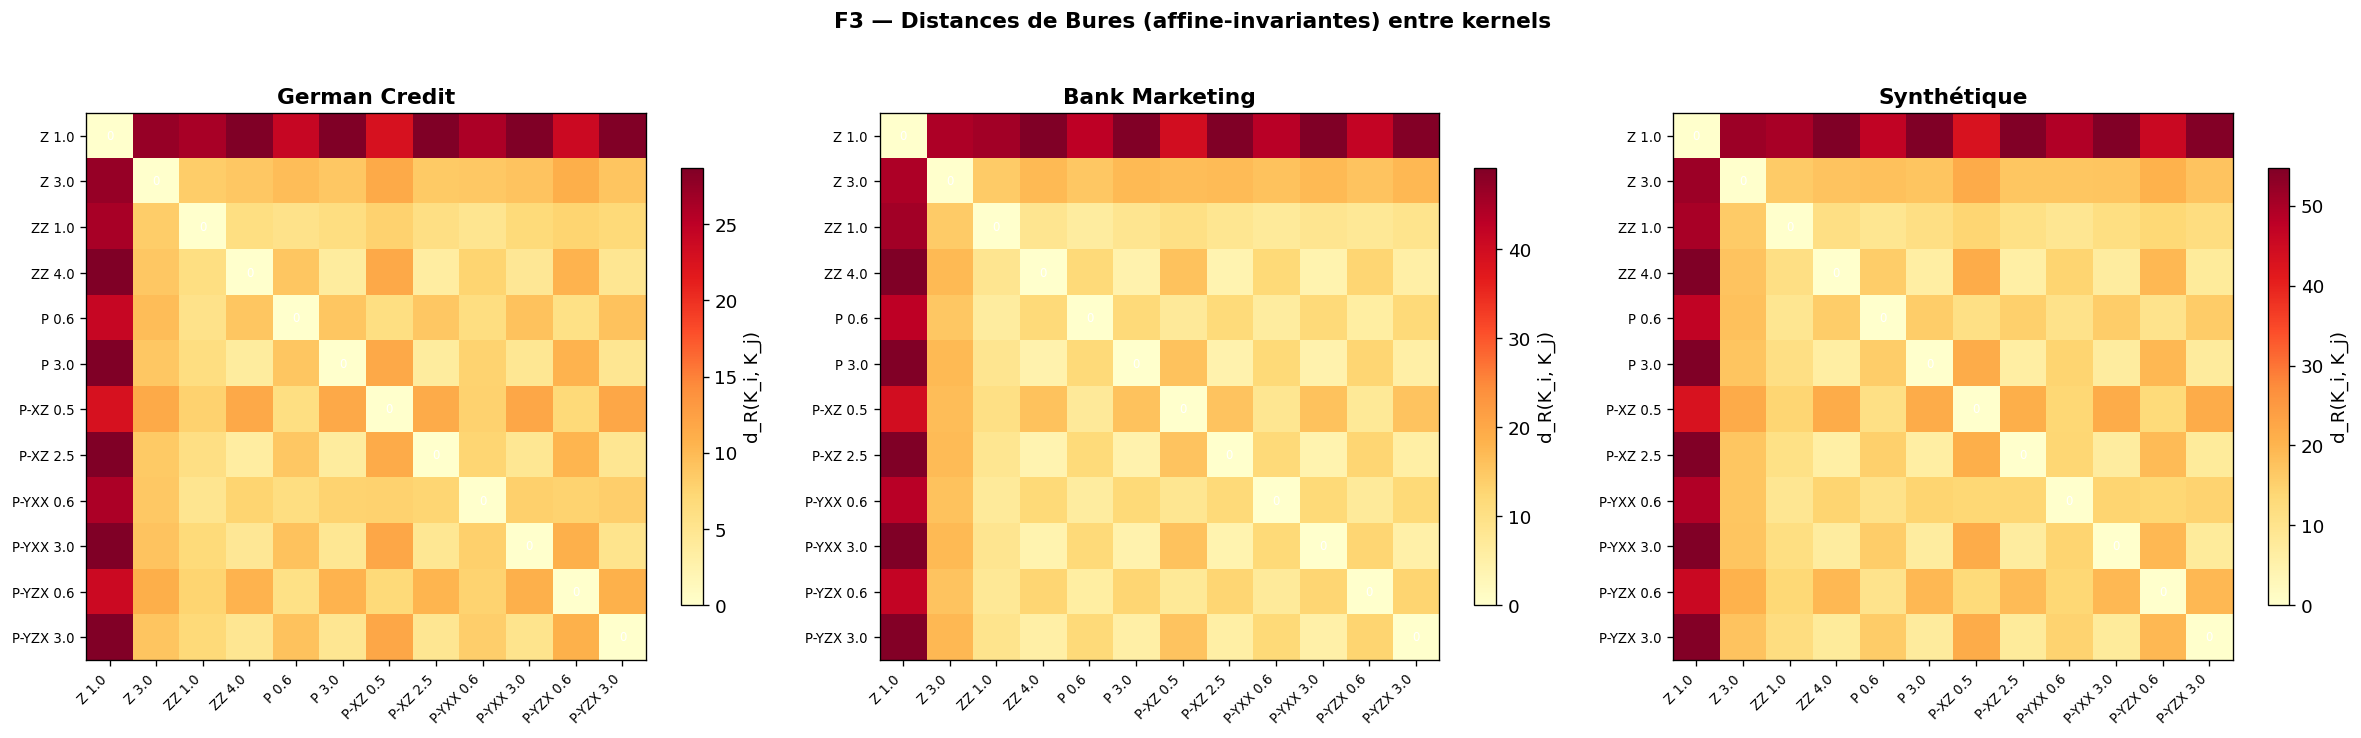

✓ F3


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
riem0 = RiemannianQMKL(verbose=False)

for ax, (ds_name, (K_list, y, labels)) in zip(axes, datasets.items()):
    print(f"Distances {ds_name}...", end=' ', flush=True)
    t0=time.time(); D = riem0.compute_pairwise_distances(K_list)
    print(f"{time.time()-t0:.1f}s")
    M=len(labels)
    im=ax.imshow(D, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(M)); ax.set_yticks(range(M))
    short=[l.replace('Pauli-','P-').replace('Pauli ','P ').replace('α=','') for l in labels]
    ax.set_xticklabels(short, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(short, fontsize=8)
    ax.set_title(ds_name, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.8, label='d_R(K_i, K_j)')
    for i in range(M): ax.text(i,i,'0',ha='center',va='center',fontsize=7,color='white')
    print(f"  d_max={D.max():.3f}, d_mean={D[D>0].mean():.3f}")

plt.suptitle("F3 — Distances de Bures (affine-invariantes) entre kernels",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT/'09_F3_bures_distances.png', dpi=150); plt.show()
print("✓ F3")

## Figure F4 — Spectres propres des combinaisons

**Design** : mêmes poids (Centered Alignment) appliqués aux 3 combinaisons.
Cela isole l'effet géométrique pur de chaque méthode.

German Credit: rang_eff — Lin=81.6, LogE=81.4, Fréchet=82.2
  λ_min — Lin=9.22e-15, LogE=1.00e-08, Fré=1.00e-08


Bank Marketing: rang_eff — Lin=42.3, LogE=40.8, Fréchet=24.6
  λ_min — Lin=3.47e-01, LogE=2.11e-02, Fré=1.19e-02


Synthétique: rang_eff — Lin=133.9, LogE=131.4, Fréchet=133.4
  λ_min — Lin=-2.55e-15, LogE=1.00e-08, Fré=1.00e-08


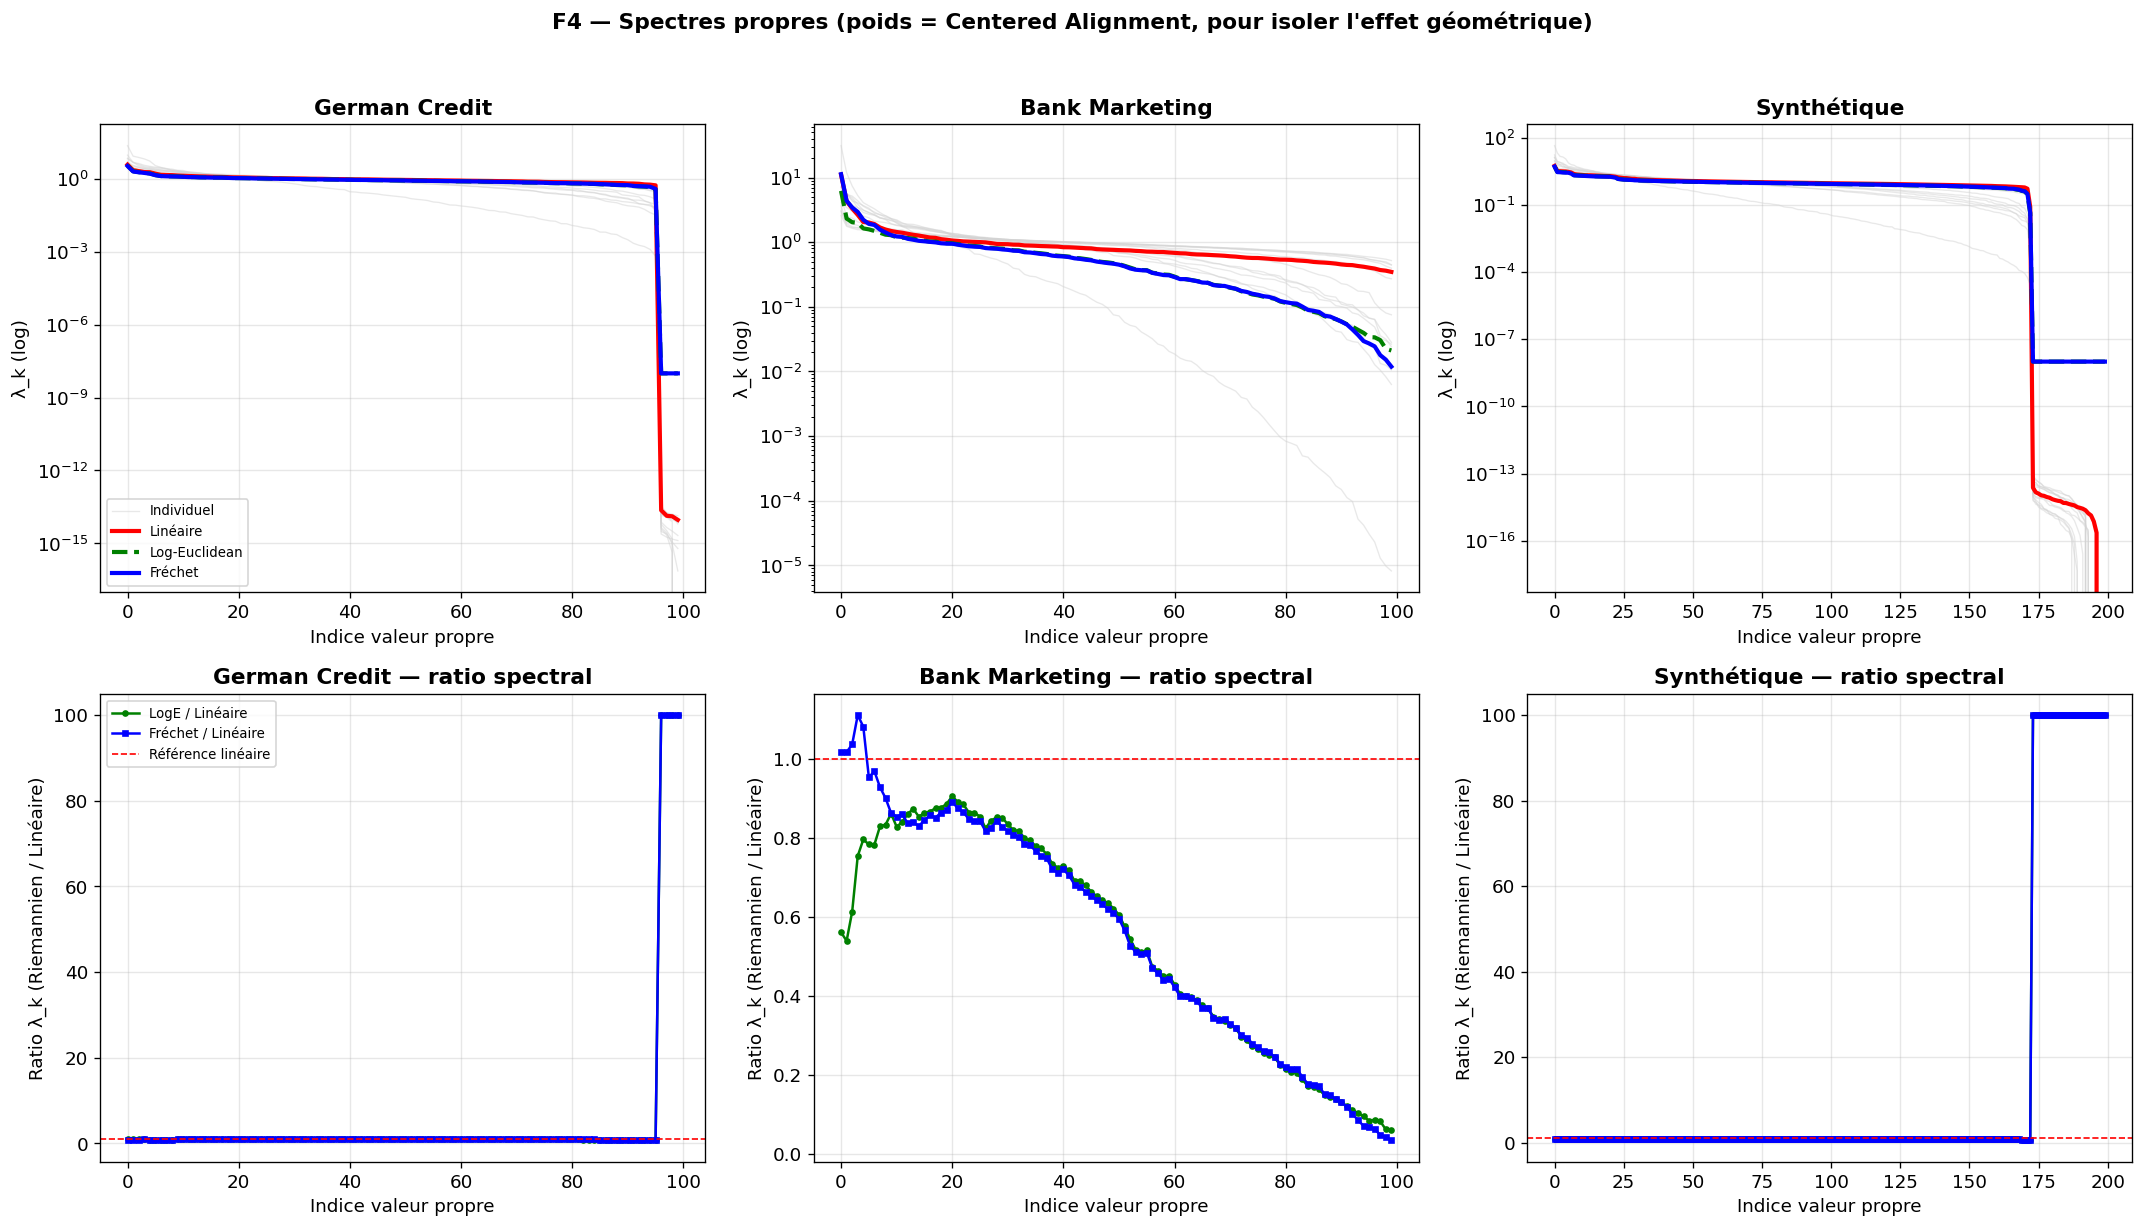

✓ F4


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col_idx, (ds_name, (K_list, y, labels)) in enumerate(datasets.items()):
    M=len(K_list); n=K_list[0].shape[0]
    K_target=(y[:,None]==y[None,:]).astype(float)

    # Compute centered alignment weights
    w=centered_alignment(K_list, K_target)
    s=np.maximum(w,0).sum(); w=np.maximum(w,0)/s if s>1e-12 else np.ones(M)/M

    K_lin  = linear_combination(K_list, w)
    K_loge = log_euclidean_mean(K_list, w, eps=1e-8)
    K_fre  = frechet_mean(K_list, w, eps=1e-8, max_iter=60, tol=1e-9)

    eig_lin  = np.sort(np.linalg.eigvalsh(K_lin))[::-1]
    eig_loge = np.sort(np.linalg.eigvalsh(K_loge))[::-1]
    eig_fre  = np.sort(np.linalg.eigvalsh(K_fre))[::-1]

    # Top subplot: full spectrum
    ax = axes[0, col_idx]
    for i, K in enumerate(K_list):
        eig_i = np.sort(np.linalg.eigvalsh(K))[::-1]
        ax.semilogy(eig_i, color='lightgray', lw=0.8, alpha=0.5,
                    label='Individuel' if i==0 else None)
    ax.semilogy(eig_lin,  'r-',  lw=2.5, label='Linéaire')
    ax.semilogy(eig_loge, 'g--', lw=2.5, label='Log-Euclidean')
    ax.semilogy(eig_fre,  'b-',  lw=2.5, label='Fréchet')
    ax.set_title(ds_name, fontweight='bold')
    ax.set_xlabel("Indice valeur propre"); ax.set_ylabel("λ_k (log)")
    if col_idx==0: ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Effective rank & min eigenvalue
    def eff_rank(e): return (np.sum(e)**2/np.sum(e**2))
    print(f"{ds_name}: rang_eff — Lin={eff_rank(eig_lin):.1f}, "
          f"LogE={eff_rank(eig_loge):.1f}, Fréchet={eff_rank(eig_fre):.1f}")
    print(f"  λ_min — Lin={eig_lin[-1]:.2e}, LogE={eig_loge[-1]:.2e}, Fré={eig_fre[-1]:.2e}")

    # Bottom subplot: ratio Riemannian/Linear
    ax2 = axes[1, col_idx]
    ratio_loge = eig_loge / np.maximum(eig_lin, 1e-10)
    ratio_fre  = eig_fre  / np.maximum(eig_lin, 1e-10)
    ax2.plot(ratio_loge, 'g-o', ms=3, lw=1.5, label='LogE / Linéaire')
    ax2.plot(ratio_fre,  'b-s', ms=3, lw=1.5, label='Fréchet / Linéaire')
    ax2.axhline(1.0, color='red', ls='--', lw=1, label='Référence linéaire')
    ax2.set_xlabel("Indice valeur propre")
    ax2.set_ylabel("Ratio λ_k (Riemannien / Linéaire)")
    ax2.set_title(f"{ds_name} — ratio spectral", fontweight='bold')
    if col_idx==0: ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)

plt.suptitle("F4 — Spectres propres (poids = Centered Alignment, pour isoler l'effet géométrique)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT/'09_F4_eigenspectra.png', dpi=150); plt.show()
print("✓ F4")

## Figure F5 — Paysage KTA sur le simplexe (M=3, hardware IBM)

Pour les 3 kernels matériel (N=30), on balaye le simplexe des poids.
La Log-Euclidean mean (pas d'itération) est utilisée pour la vitesse,
puis on compare au maximum Fréchet exact au point optimal.

Hardware: M=3, N=30


Landscape: 465 points en 0.9s


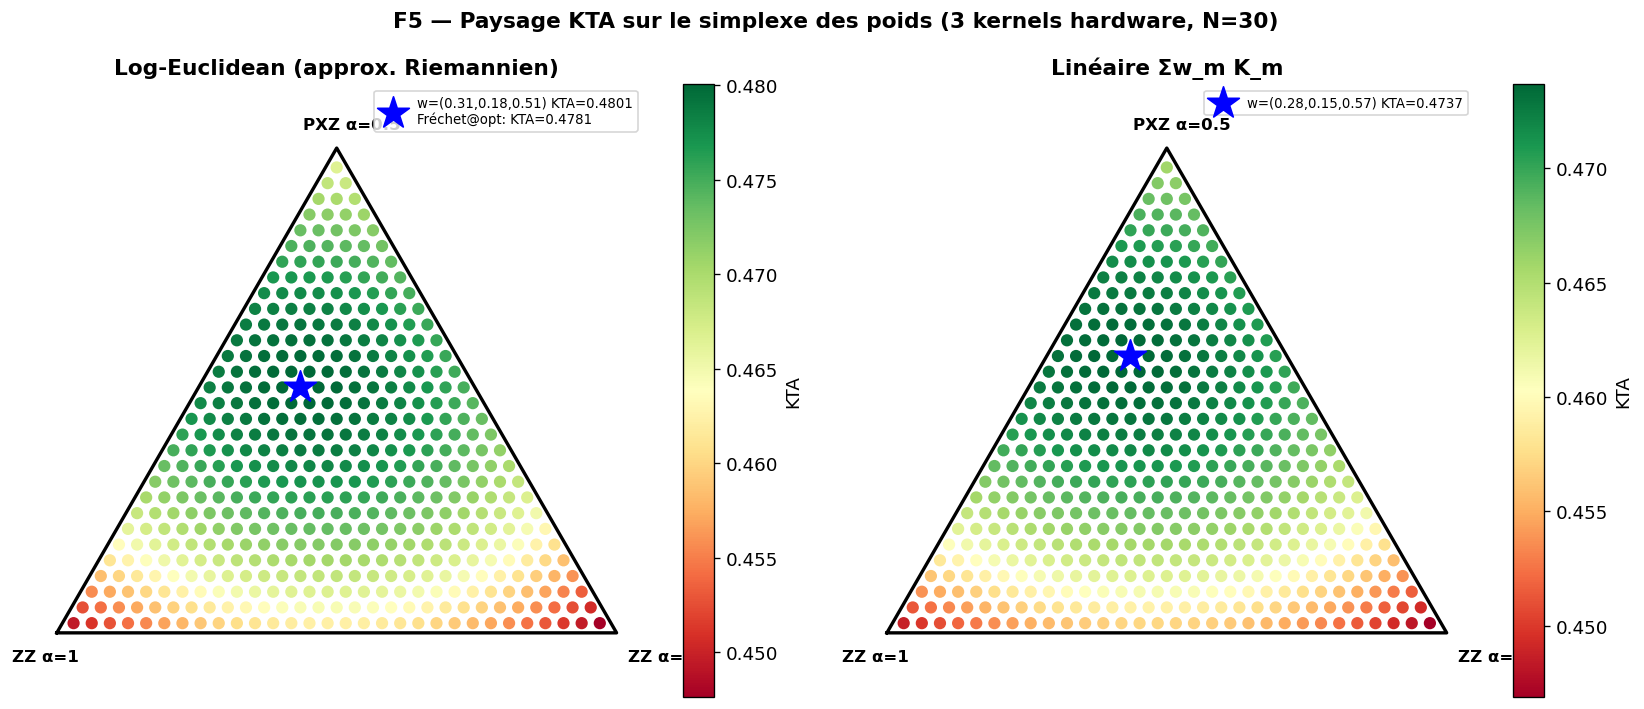

✓ F5


In [7]:
hw_names  = ['ZZ_a1.0','ZZ_a4.0','pauli_XZ_a0.5']
hw_labels = ['ZZ α=1','ZZ α=4','PXZ α=0.5']
K_hw  = [np.load(HW/f'K_hw_fin_{n}.npy') for n in hw_names]
K_sim = [np.load(CACHE/f'final_sim_fin_{n}.npy') for n in hw_names]
_, y_hw = load_dataset('german_credit', n_samples=30, random_state=42)
K_target_hw = (y_hw[:,None]==y_hw[None,:]).astype(float)
print(f"Hardware: M=3, N={len(y_hw)}")

def kta_fn(K, Kt):
    num=np.sum(K*Kt); den=np.sqrt(np.sum(K*K)*np.sum(Kt*Kt)+1e-24)
    return float(num/den)

N_GRID = 30
rows = []
t0=time.time()
for a in np.linspace(0.02, 0.96, N_GRID):
    for b in np.linspace(0.02, 0.96, N_GRID):
        c = 1.0-a-b
        if c < 0.02: continue
        w = np.array([a,b,c])
        try:
            K_loge = log_euclidean_mean(K_hw, w, eps=1e-8)
            K_lin  = linear_combination(K_hw, w)
            rows.append({'a':a,'b':b,'c':c,
                         'kta_loge': kta_fn(K_loge, K_target_hw),
                         'kta_lin':  kta_fn(K_lin,  K_target_hw)})
        except: pass
print(f"Landscape: {len(rows)} points en {time.time()-t0:.1f}s")

import pandas as pd
df = pd.DataFrame(rows)

def bary2cart(a,b,c):
    x = 0.5*(2*b+c)/(a+b+c); y = (np.sqrt(3)/2)*c/(a+b+c)
    return x, y
df['x'], df['y'] = bary2cart(df.a, df.b, df.c)

# Compute Fréchet at LogE optimum (fast since M=3, N=30)
best_loge = df.loc[df.kta_loge.idxmax()]
w_opt = np.array([best_loge.a, best_loge.b, best_loge.c])
K_fre_opt = frechet_mean(K_hw, w_opt, eps=1e-8, max_iter=80, tol=1e-10)
kta_fre_opt = kta_fn(K_fre_opt, K_target_hw)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, col, title in zip(axes,
                           ['kta_loge','kta_lin'],
                           ['Log-Euclidean (approx. Riemannien)','Linéaire Σw_m K_m']):
    sc = ax.scatter(df.x, df.y, c=df[col], cmap='RdYlGn', s=40,
                    vmin=df[col].min(), vmax=df[col].max())
    plt.colorbar(sc, ax=ax, label='KTA')
    best = df.loc[df[col].idxmax()]
    label_best = (f"w=({best.a:.2f},{best.b:.2f},{best.c:.2f})"
                  + f" KTA={best[col]:.4f}")
    if col=='kta_loge':
        label_best += f"\nFréchet@opt: KTA={kta_fre_opt:.4f}"
    ax.scatter(best.x, best.y, marker='*', s=400, c='blue', zorder=6, label=label_best)
    v = [(0,0),(1,0),(0.5,np.sqrt(3)/2),(0,0)]
    ax.plot([p[0] for p in v],[p[1] for p in v],'k-',lw=2)
    ax.text(-0.08,-0.05, hw_labels[0], fontsize=10, fontweight='bold')
    ax.text(1.02,-0.05,  hw_labels[1], fontsize=10, fontweight='bold')
    ax.text(0.44,0.9,    hw_labels[2], fontsize=10, fontweight='bold')
    ax.set_title(title, fontweight='bold'); ax.axis('equal'); ax.axis('off')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle("F5 — Paysage KTA sur le simplexe des poids (3 kernels hardware, N=30)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT/'09_F5_kta_landscape.png', dpi=150); plt.show()
print("✓ F5")

## Figure F6 — Comparaison AUC multi-runs (20 tirages)

**Protocole** : pour chaque split, on calcule les poids par Centered Alignment
sur le train, puis on applique les TROIS types de combinaison.
Cela isole l'effet géométrique des poids.

In [8]:
def _build_tgt(y): return (y[:,None]==y[None,:]).astype(float)

def _ensure_psd(K, margin=1e-8):
    me=np.min(np.linalg.eigvalsh(K))
    return K+(abs(me)+margin)*np.eye(K.shape[0]) if me<0 else K

def _score(svm, K_te, y_te, scoring='roc_auc'):
    from sklearn.metrics import roc_auc_score, accuracy_score
    if scoring=='roc_auc':
        return roc_auc_score(y_te, svm.predict_proba(K_te)[:,1])
    return accuracy_score(y_te, svm.predict(K_te))

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

def multi_run_riemannian(K_list_full, y_full, n_runs=20, test_size=0.33,
                          C=1.0, eps=1e-8, seed=42):
    """Run 20 splits comparing Linear / LogE / Frechet (same Centered weights)."""
    methods = ['Average','Centered','SDP','Linear+Centered','LogE+Centered','Fréchet+Centered']
    results = {m: [] for m in methods}
    n=len(y_full)
    for run in range(n_runs):
        idx=np.arange(n)
        itr,ite=train_test_split(idx,test_size=test_size,random_state=seed+run,
                                  stratify=y_full)
        ytr,yte=y_full[itr],y_full[ite]
        Ktr=[K[np.ix_(itr,itr)] for K in K_list_full]
        Kte=[K[np.ix_(ite,itr)] for K in K_list_full]
        Kt=_build_tgt(ytr)
        M=len(Ktr)
        w_avg=np.ones(M)/M
        w_cen=centered_alignment(Ktr,Kt); s=np.maximum(w_cen,0).sum()
        w_cen=np.maximum(w_cen,0)/s if s>1e-12 else w_avg
        w_sdp=sdp_alignment(Ktr,Kt); s=np.maximum(w_sdp,0).sum()
        w_sdp=np.maximum(w_sdp,0)/s if s>1e-12 else w_avg

        combos = [
            ('Average',         w_avg, 'linear'),
            ('Centered',        w_cen, 'linear'),
            ('SDP',             w_sdp, 'linear'),
            ('Linear+Centered', w_cen, 'linear'),
            ('LogE+Centered',   w_cen, 'log_euclidean'),
            ('Fréchet+Centered',w_cen, 'frechet'),
        ]
        for mname, w, ctype in combos:
            try:
                if ctype=='linear':
                    Kc_tr=linear_combination(Ktr,w)
                elif ctype=='log_euclidean':
                    Kc_tr=log_euclidean_mean(Ktr,w,eps=eps)
                else:
                    Kc_tr=frechet_mean(Ktr,w,eps=eps,max_iter=40,tol=1e-8)
                Kc_te=linear_combination(Kte,w)
                Kc_tr=_ensure_psd(Kc_tr)
                svm=SVC(kernel='precomputed',C=C,probability=True)
                svm.fit(Kc_tr,ytr)
                results[mname].append(_score(svm,Kc_te,yte))
            except Exception as e:
                results[mname].append(float('nan'))
    return results

comparison_results={}
for ds_name,(K_list,y,labels) in datasets.items():
    print(f"\n{ds_name}...", flush=True)
    t0=time.time()
    res=multi_run_riemannian(K_list,y,n_runs=N_RUNS,seed=SEED,C=C_SVM)
    comparison_results[ds_name]=res
    print(f"  {time.time()-t0:.0f}s")
    for m,s in sorted({m:np.nanmean(v) for m,v in res.items()}.items(),
                      key=lambda x:-x[1]):
        print(f"  {m:25s}: {np.nanmean(res[m]):.4f} ± {np.nanstd(res[m],ddof=1):.4f}")


German Credit...


  9s
  SDP                      : 0.5683 ± 0.1402
  Average                  : 0.5300 ± 0.1340
  Linear+Centered          : 0.5157 ± 0.1135
  Fréchet+Centered         : 0.4965 ± 0.1108
  LogE+Centered            : 0.4904 ± 0.1091
  Centered                 : 0.4800 ± 0.1134

Bank Marketing...


  31s
  LogE+Centered            : 0.7828 ± 0.0960
  Fréchet+Centered         : 0.7728 ± 0.0960
  Centered                 : 0.7655 ± 0.0876
  Linear+Centered          : 0.7655 ± 0.0876
  SDP                      : 0.7405 ± 0.0814
  Average                  : 0.7060 ± 0.1280

Synthétique...


  62s
  SDP                      : 0.5913 ± 0.0438
  Average                  : 0.5469 ± 0.0776
  LogE+Centered            : 0.5354 ± 0.0712
  Centered                 : 0.5198 ± 0.0744
  Linear+Centered          : 0.5182 ± 0.0741
  Fréchet+Centered         : 0.5091 ± 0.0790


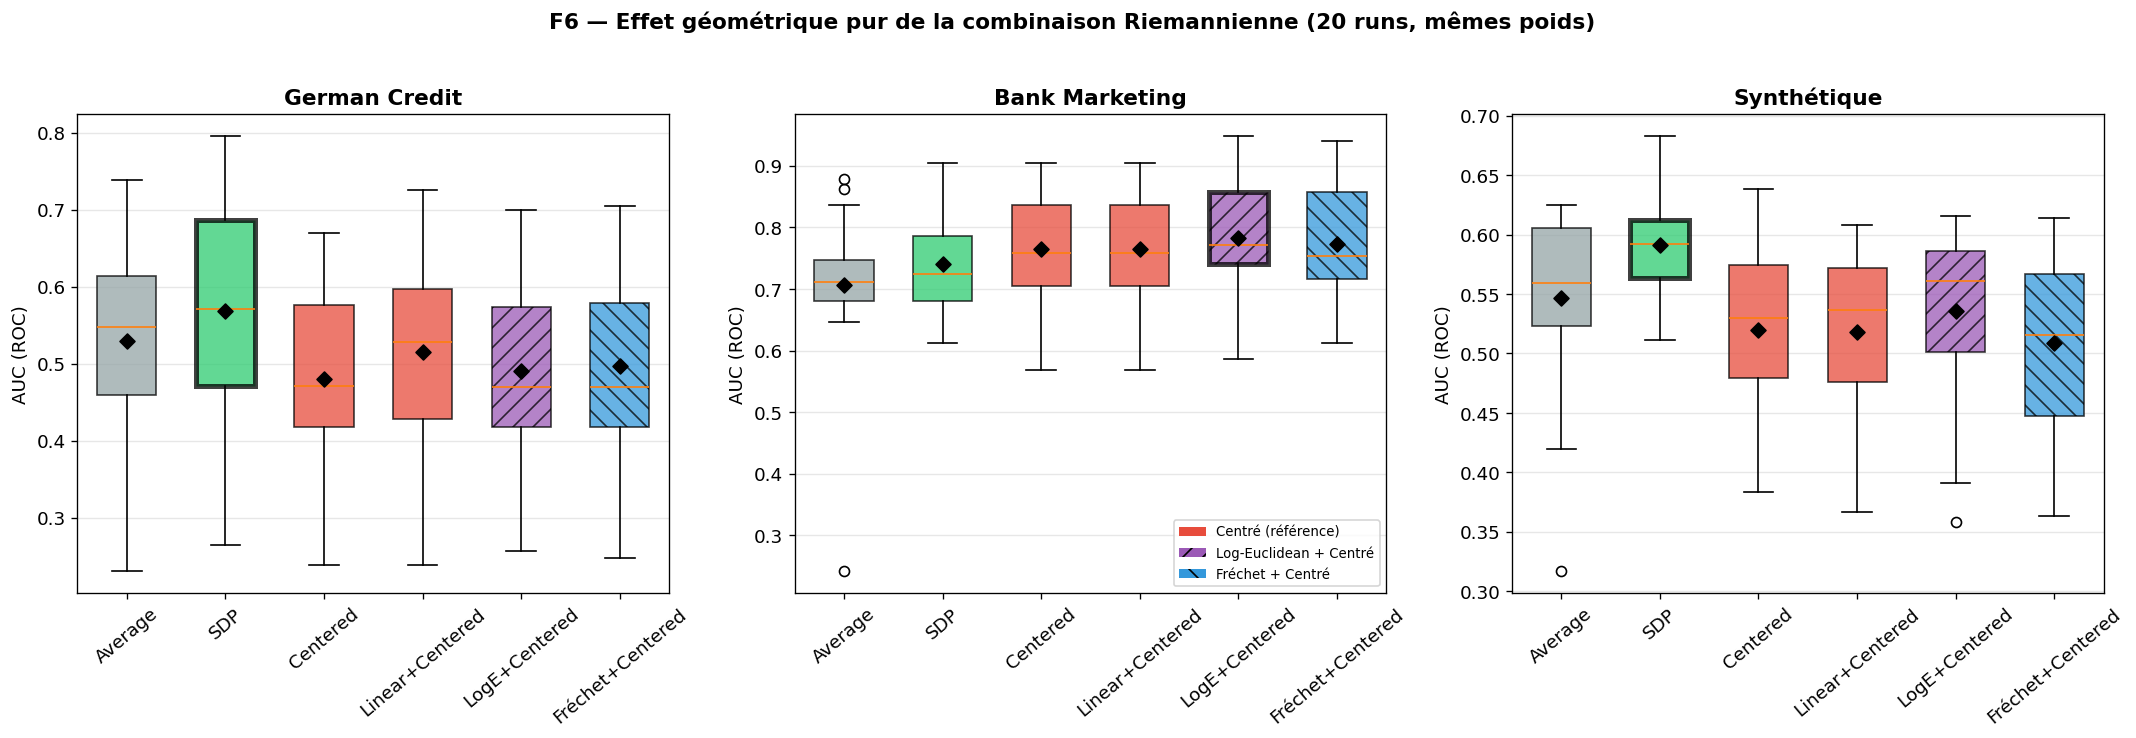

✓ F6


In [9]:
method_order = ['Average','SDP','Centered',
                'Linear+Centered','LogE+Centered','Fréchet+Centered']
colors = ['#95a5a6','#2ecc71','#e74c3c','#e74c3c','#9b59b6','#3498db']
hatches= [None,None,None,None,'//','\\\\']

fig, axes = plt.subplots(1,3,figsize=(18,6))
for ax,(ds_name,results) in zip(axes,comparison_results.items()):
    avail=[m for m in method_order if m in results]
    data=[results[m] for m in avail]
    bp=ax.boxplot(data,labels=avail,patch_artist=True,widths=0.6)
    for patch,c,h in zip(bp['boxes'],
                          [colors[method_order.index(m)] for m in avail],
                          [hatches[method_order.index(m)] for m in avail]):
        patch.set_facecolor(c); patch.set_alpha(0.75)
        if h: patch.set_hatch(h)
    means=[np.nanmean(results[m]) for m in avail]
    ax.scatter(range(1,len(avail)+1),means,marker='D',color='black',s=40,zorder=5)
    best_i=int(np.nanargmax(means))
    bp['boxes'][best_i].set_linewidth(3)
    ax.set_ylabel('AUC (ROC)'); ax.set_title(ds_name,fontweight='bold')
    ax.tick_params(axis='x',rotation=40); ax.grid(axis='y',alpha=0.3)

from matplotlib.patches import Patch
legend_elems=[
    Patch(facecolor='#e74c3c',label='Centré (référence)'),
    Patch(facecolor='#9b59b6',hatch='//',label='Log-Euclidean + Centré'),
    Patch(facecolor='#3498db',hatch='\\\\',label='Fréchet + Centré'),
]
axes[1].legend(handles=legend_elems,fontsize=8,loc='lower right')

plt.suptitle('F6 — Effet géométrique pur de la combinaison Riemannienne (20 runs, mêmes poids)',
             fontsize=13,fontweight='bold',y=1.02)
plt.tight_layout()
plt.savefig(OUT/'09_F6_auc_comparison.png',dpi=150); plt.show()
print("✓ F6")

## Figure F7 — Application hardware IBM Torino (M=3, N=30)

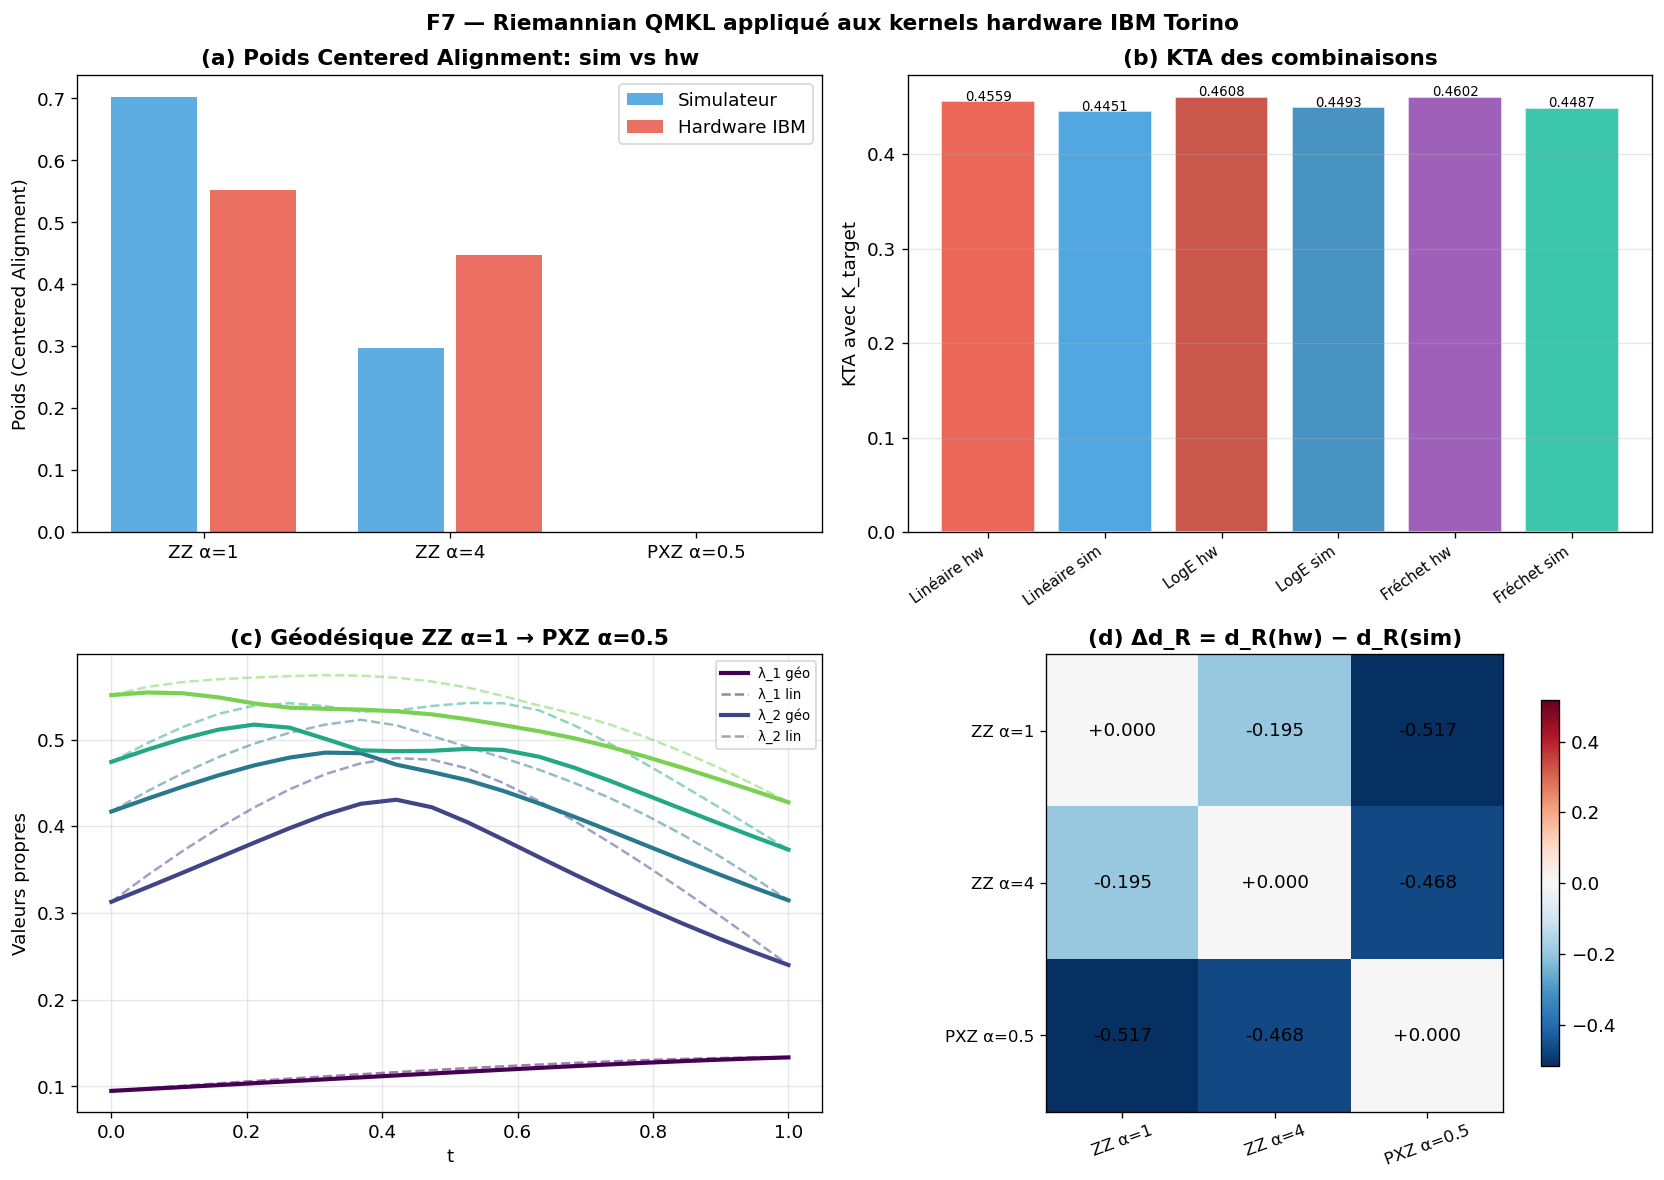

✓ F7


In [10]:
fig, axes = plt.subplots(2,2,figsize=(14,10))

# (a) Poids Centered Alignment: hardware vs simulateur
ax=axes[0,0]
Kt_hw=_build_tgt(y_hw)
w_hw_cen=centered_alignment(K_hw,Kt_hw)
wh=np.maximum(w_hw_cen,0); wh/=wh.sum()
w_sim_cen=centered_alignment(K_sim,Kt_hw)
ws=np.maximum(w_sim_cen,0); ws/=ws.sum()

x=np.arange(3)
ax.bar(x-0.2,ws,0.35,label='Simulateur',color='#3498db',alpha=0.8)
ax.bar(x+0.2,wh,0.35,label='Hardware IBM',color='#e74c3c',alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(hw_labels)
ax.set_ylabel('Poids (Centered Alignment)'); ax.legend()
ax.set_title('(a) Poids Centered Alignment: sim vs hw',fontweight='bold')

# (b) KTA des 3 types de combinaison
ax=axes[0,1]
combos_hw=[
    ('Linéaire hw',  linear_combination(K_hw, wh), '#e74c3c'),
    ('Linéaire sim', linear_combination(K_sim,ws), '#3498db'),
    ('LogE hw',      log_euclidean_mean(K_hw,wh),  '#c0392b'),
    ('LogE sim',     log_euclidean_mean(K_sim,ws), '#2980b9'),
    ('Fréchet hw',   frechet_mean(K_hw,wh,max_iter=80), '#8e44ad'),
    ('Fréchet sim',  frechet_mean(K_sim,ws,max_iter=80),'#1abc9c'),
]
kta_vals=[kta_fn(K,Kt_hw) for _,K,_ in combos_hw]
names_c=[n for n,_,_ in combos_hw]
cols_c=[c for _,_,c in combos_hw]
bars=ax.bar(range(len(names_c)),kta_vals,color=cols_c,alpha=0.85,edgecolor='white')
ax.set_xticks(range(len(names_c))); ax.set_xticklabels(names_c,rotation=35,ha='right',fontsize=9)
ax.set_ylabel('KTA avec K_target'); ax.set_title('(b) KTA des combinaisons',fontweight='bold')
for i,(v,b) in enumerate(zip(kta_vals,bars)):
    ax.text(b.get_x()+b.get_width()/2, v+0.001, f'{v:.4f}',ha='center',fontsize=8)
ax.grid(axis='y',alpha=0.3)

# (c) Geodesic between most distant pair
ax=axes[1,0]
D_hw=riem0.compute_pairwise_distances(K_hw)
i0,i1=np.unravel_index(np.triu(D_hw,1).argmax(),D_hw.shape)
ts,path=geodesic_path(K_hw[i0],K_hw[i1],n_points=20)
pl=[t*K_hw[i1]+(1-t)*K_hw[i0] for t in ts]
N_eig=min(5,K_hw[0].shape[0])
for k in range(N_eig):
    c=plt.cm.viridis(k/N_eig)
    ax.plot(ts,[np.linalg.eigvalsh(K)[k] for K in path],'-',color=c,lw=2.5,
            label=f'λ_{k+1} géo' if k<2 else None)
    ax.plot(ts,[np.linalg.eigvalsh(K)[k] for K in pl],'--',color=c,lw=1.5,alpha=0.5,
            label=f'λ_{k+1} lin' if k<2 else None)
ax.set_xlabel('t'); ax.set_ylabel('Valeurs propres')
ax.set_title(f'(c) Géodésique {hw_labels[i0]} → {hw_labels[i1]}',fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (d) Pairwise distances: hw vs sim
ax=axes[1,1]
D_sim=riem0.compute_pairwise_distances(K_sim)
diff_D=D_hw-D_sim
vmax=max(abs(diff_D.min()),abs(diff_D.max()),1e-4)
im=ax.imshow(diff_D,cmap='RdBu_r',vmin=-vmax,vmax=vmax)
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(hw_labels,rotation=20,fontsize=10)
ax.set_yticklabels(hw_labels,fontsize=10)
ax.set_title('(d) Δd_R = d_R(hw) − d_R(sim)',fontweight='bold')
plt.colorbar(im,ax=ax,shrink=0.8)
for i in range(3):
    for j in range(3):
        ax.text(j,i,f'{diff_D[i,j]:+.3f}',ha='center',va='center',fontsize=11)

plt.suptitle("F7 — Riemannian QMKL appliqué aux kernels hardware IBM Torino",
             fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(OUT/'09_F7_hardware.png',dpi=150); plt.show()
print("✓ F7")

## Figure F8 — Tableau de synthèse

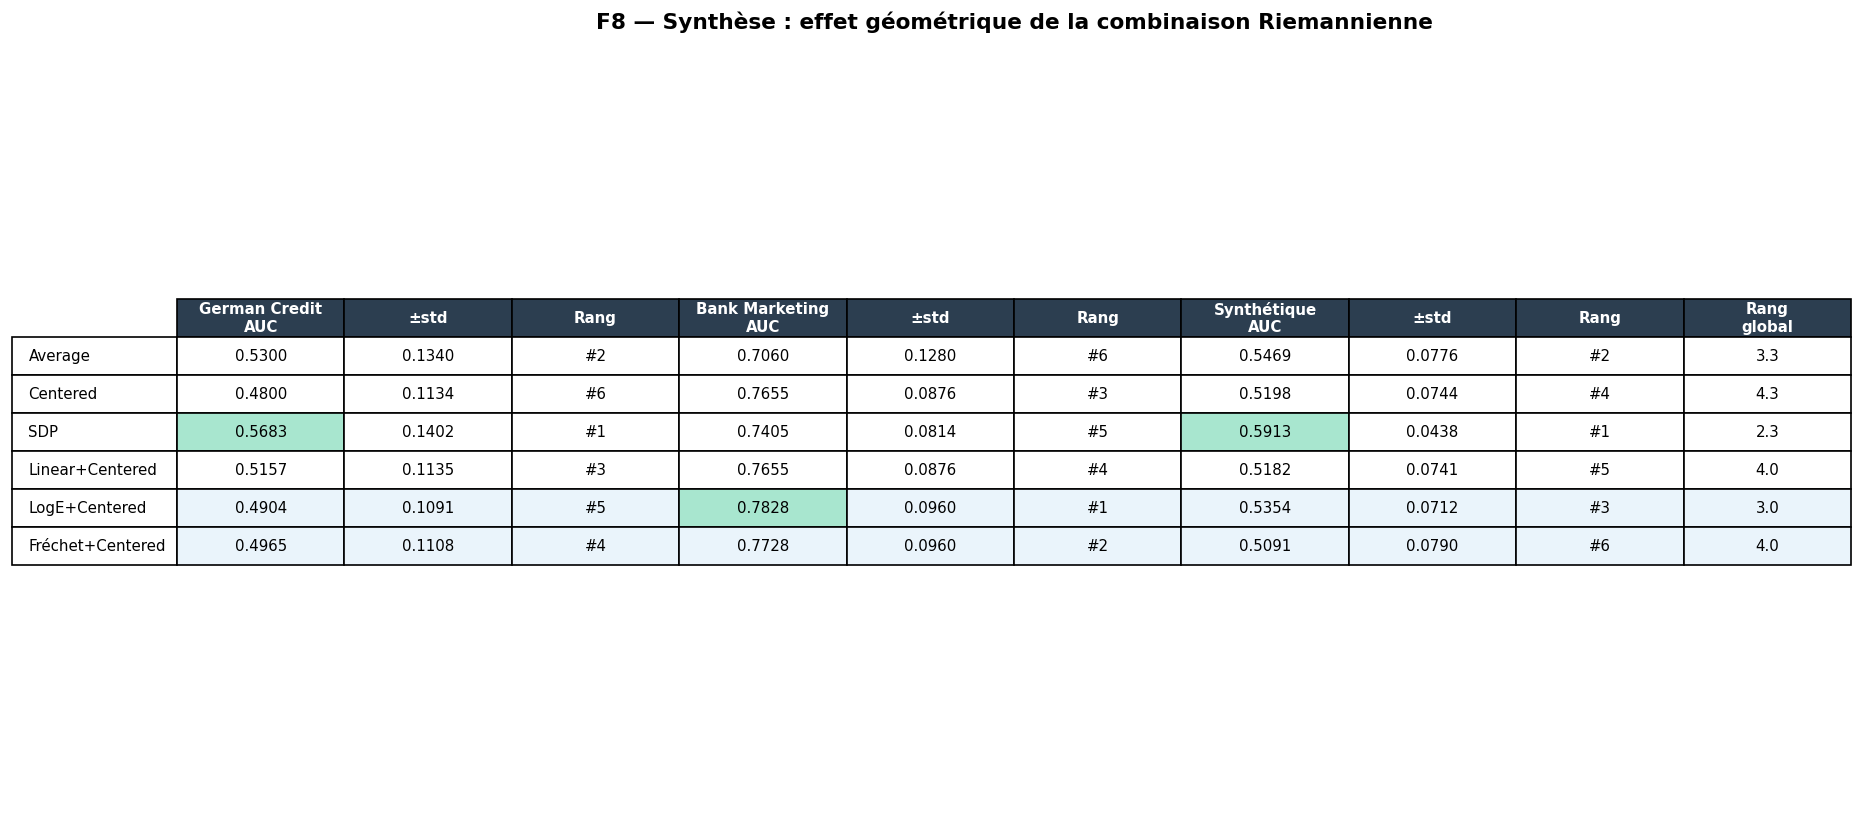

✓ F8


In [11]:
fig, ax = plt.subplots(figsize=(18, 8))
ax.axis('off')
ds_names=list(comparison_results.keys())
display_methods=['Average','Centered','SDP','Linear+Centered','LogE+Centered','Fréchet+Centered']

col_labels=[]
for ds in ds_names: col_labels+=[f'{ds}\nAUC','±std','Rang']
col_labels.append('Rang\nglobal')

table_data=[]
for method in display_methods:
    row=[]; ranks=[]
    for ds in ds_names:
        res=comparison_results[ds]
        if method not in res: row+=['—','—','—']; continue
        sc=res[method]; mn,sd=np.nanmean(sc),np.nanstd(sc,ddof=1)
        all_m={m:np.nanmean(res[m]) for m in display_methods if m in res}
        rank=sorted(all_m,key=lambda x:-all_m[x]).index(method)+1              if method in all_m else len(all_m)
        row+=[f'{mn:.4f}',f'{sd:.4f}',f'#{rank}']; ranks.append(rank)
    row.append(f'{np.mean(ranks):.1f}' if ranks else '—')
    table_data.append(row)

table=ax.table(cellText=table_data,rowLabels=display_methods,
               colLabels=col_labels,cellLoc='center',loc='center')
table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1.0, 1.9)
for j in range(len(col_labels)):
    table[0,j].set_facecolor('#2c3e50')
    table[0,j].set_text_props(color='white',fontweight='bold')
for i,m in enumerate(display_methods):
    if 'LogE' in m or 'Fréchet' in m:
        for j in range(len(col_labels)):
            if table[i+1,j].get_facecolor()[0]>0.9:
                table[i+1,j].set_facecolor('#eaf4fb')
for d_idx in range(len(ds_names)):
    col_auc=d_idx*3
    vals=[(i,float(table_data[i][col_auc])) for i in range(len(display_methods))
          if table_data[i][col_auc]!='—']
    if vals:
        best_i=max(vals,key=lambda x:x[1])[0]
        table[best_i+1,col_auc].set_facecolor('#a8e6cf')

plt.title("F8 — Synthèse : effet géométrique de la combinaison Riemannienne",
          fontsize=13,fontweight='bold',pad=20)
plt.savefig(OUT/'09_F8_synthesis_table.png',dpi=150,bbox_inches='tight')
plt.show(); print("✓ F8")

In [12]:
print("="*70)
print("RÉSUMÉ RIEMANNIAN QMKL")
print("="*70)
print("\nProposition : remplacer K_lin = Σw_m K_m par K★ = FréchetMean(K_1..K_M;w)")
print("Design : mêmes poids (Centered Alignment) pour isoler l'effet géométrique")
print()
for ds_name,results in comparison_results.items():
    mn_cen=np.nanmean(results['Centered'])
    mn_loge=np.nanmean(results.get('LogE+Centered',[float('nan')]))
    mn_fre=np.nanmean(results.get('Fréchet+Centered',[float('nan')]))
    print(f"{ds_name}:")
    print(f"  Centered (linéaire): {mn_cen:.4f}")
    print(f"  Log-Euclidean:       {mn_loge:.4f}  (Δ={mn_loge-mn_cen:+.4f})")
    print(f"  Fréchet:             {mn_fre:.4f}  (Δ={mn_fre-mn_cen:+.4f})")

print(f"\nFigures sauvegardées dans {OUT}")
print("="*70)

RÉSUMÉ RIEMANNIAN QMKL

Proposition : remplacer K_lin = Σw_m K_m par K★ = FréchetMean(K_1..K_M;w)
Design : mêmes poids (Centered Alignment) pour isoler l'effet géométrique

German Credit:
  Centered (linéaire): 0.4800
  Log-Euclidean:       0.4904  (Δ=+0.0104)
  Fréchet:             0.4965  (Δ=+0.0165)
Bank Marketing:
  Centered (linéaire): 0.7655
  Log-Euclidean:       0.7828  (Δ=+0.0172)
  Fréchet:             0.7728  (Δ=+0.0073)
Synthétique:
  Centered (linéaire): 0.5198
  Log-Euclidean:       0.5354  (Δ=+0.0156)
  Fréchet:             0.5091  (Δ=-0.0107)

Figures sauvegardées dans /Users/raph/Desktop/Academic/Projet infoQ/Projet-QMKL-Finance/results/09
